In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.metrics import f1_score, classification_report
from itertools import product
import matplotlib.pyplot as plt

maximize the macro F1 SCORE, balance the precision and recall, and find the optimal thresholds for categorizing data into 'H', 'M', and 'L' based on a score column and true labels.

In [2]:
validation_df = pd.read_csv('2026-03-11T22_05_20+00_00_urh.csv')
print(validation_df.columns)


Index(['id', 'created_at', 'validation', 'user_id', 'output_id',
       'output_model', 'output_model_city_name', 'output_model_city_country',
       'output_model_subdomain_name', 'output_result', 'output_latitude',
       'output_longitude'],
      dtype='object')


### Kano - Emergency Obstetric Care (EmOC) Accessibility

In [3]:
# Select pilot city
pilot = 'Kano'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [4]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (24810, 12)


output_model_subdomain_name
Morphological Informality                      11009
Emergency Obstetric Care Access Deprivation     4434
General Healthcare Access Deprivation           4038
Road Access Deprivation                         3581
Drinking Water Access Deprivation               1748
Name: count, dtype: int64

In [5]:
# Enter subdomain
subdomain = 'Emergency Obstetric Care Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
141,3e2c4ed2-5d70-4366-87cb-31b2fc708ad7,2025-05-22T14:30:43.470779+00:00,1.0,e039d820-cd6e-4360-b92b-8729c3354bd4,594583b8-21ac-40a7-8bad-47d5d4853571,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,12.040564,8.572567
197,b9d75a79-f95b-474a-b635-ae5dabc701d4,2025-05-22T14:31:08.713542+00:00,1.0,e039d820-cd6e-4360-b92b-8729c3354bd4,f699230f-14d5-4309-a765-632849cbe817,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,12.041379,8.573595
262,46c1fe60-2017-418a-9c8e-58fc9d3f0313,2025-05-22T14:31:12.345971+00:00,1.0,e039d820-cd6e-4360-b92b-8729c3354bd4,70f2736e-12a6-4eb2-9485-8538bdeade0f,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,12.039748,8.574574
263,af24f34b-f8cf-4d1b-94fb-0aa451766abe,2025-05-22T14:31:17.362707+00:00,0.0,11072e21-e8b7-45e6-88ff-b1569e233941,59de5b75-eb3e-4c14-b789-57bae0f34653,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,0,12.034854,8.563351
325,64490bd3-c8bf-4748-9e8a-249d070c7397,2025-05-20T11:51:06.297704+00:00,1.0,3617df69-2dae-48f8-b1dc-7f4809b0d7ad,c9d663ea-b9d9-461b-ab7a-67293f6c20f7,4c44b4ef-407a-469c-af5d-185aa83c7133,Kano,Nigeria,Emergency Obstetric Care Access Deprivation,1,11.995702,8.521111


In [6]:
accessibility_index_Kano = gpd.read_file('deprivation-classification-Kano.gpkg')
print(accessibility_index_Kano.columns)


Index(['grid_id', 'longitude', 'latitude', 'lon_min', 'lon_max', 'lat_min',
       'lat_max', 'Accessibility_Index_Standard', 'result', 'focused',
       'geometry'],
      dtype='object')


In [7]:
# special validation results to the accessibility index dataset
accessibility_index_Kano = accessibility_index_Kano.merge(
    par_subdomain[['output_latitude', 'output_longitude', 'output_result', 'validation']],
    left_on  = [accessibility_index_Kano['latitude'].round(7), accessibility_index_Kano['longitude'].round(7)],
    right_on = [par_subdomain['output_latitude'].round(7), par_subdomain['output_longitude'].round(7)],
    how = 'inner'
).drop(columns=['output_latitude', 'output_longitude'])

print(accessibility_index_Kano.head())


       key_0     key_1  grid_id  longitude   latitude   lon_min   lon_max  \
0  12.096848  8.431029       16   8.431029  12.096848  8.430515  8.431543   
1  12.087059  8.445002       24   8.445002  12.087059  8.444488  8.445516   
2  12.087059  8.445002       24   8.445002  12.087059  8.444488  8.445516   
3  12.087059  8.447026       27   8.447026  12.087059  8.446512  8.447539   
4  12.087059  8.447026       27   8.447026  12.087059  8.446512  8.447539   

     lat_min    lat_max  Accessibility_Index_Standard  result  focused  \
0  12.096440  12.097256                      0.005863       1        1   
1  12.086651  12.087467                      0.014871       1        0   
2  12.086651  12.087467                      0.014871       1        0   
3  12.086651  12.087467                      0.018920       1        0   
4  12.086651  12.087467                      0.018920       1        0   

                                            geometry  output_result  \
0  POLYGON ((8.43053 

In [12]:
print(accessibility_index_Kano.shape[0])
print(accessibility_index_Kano['validation'].value_counts())

4434
validation
2.0    2033
1.0    1469
0.0     932
Name: count, dtype: int64


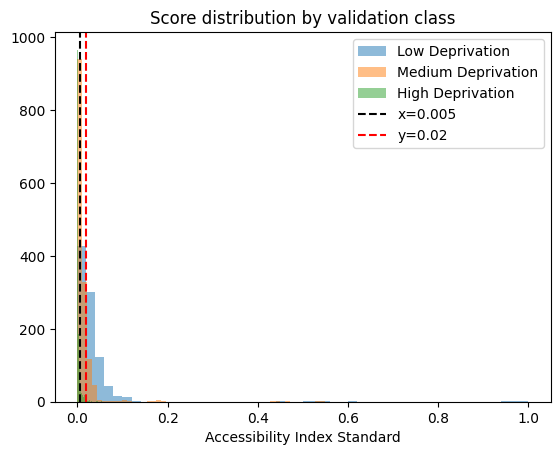

In [10]:
for label, name in zip([0, 1, 2], ['Low Deprivation', 'Medium Deprivation', 'High Deprivation']):
    subset = accessibility_index_Kano[accessibility_index_Kano['validation'] == label]['Accessibility_Index_Standard']
    plt.hist(subset, bins=50, alpha=0.5, label=name)

plt.axvline(0.005, color='black', linestyle='--', label='x=0.005')
plt.axvline(0.02, color='red', linestyle='--', label='y=0.02')
plt.legend()
plt.xlabel('Accessibility Index Standard')
plt.title('Score distribution by validation class')
plt.show()

In [ ]:
# Fix dtype
accessibility_index_Kano['validation'] = accessibility_index_Kano['validation'].astype(int)

def optimize_thresholds_f1(df, score_col='Accessibility_Index_Standard', label_col='validation', n=100):
    candidates  = np.linspace(df[score_col].min(), df[score_col].max(), n)
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1

    for i, x in enumerate(candidates):
        for y in candidates[i+1:]:
            preds = np.where(scores > y, 0, np.where(scores > x, 1, 2))
            f1 = f1_score(true_labels, preds, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_x, best_y = f1, x, y

    return best_x, best_y, best_f1

# Coarse search
coarse_x, coarse_y, _ = optimize_thresholds_f1(accessibility_index_Kano)

# Fine search within ±0.05 of coarse result
def fine_search(df, cx, cy, score_col='Accessibility_Index_Standard', label_col='validation', n=100):
    df_fine = df.copy()
    # Temporarily override candidates range
    return optimize_thresholds_f1(
        df[df[score_col].between(max(0, cx-0.05), min(1, cy+0.05))],
        n=n
    )

optimal_x, optimal_y, best_f1 = fine_search(accessibility_index_Kano, coarse_x, coarse_y)

print(f"x={optimal_x:.4f}, y={optimal_y:.4f}, Macro F1={best_f1:.4f}")

x=0.0050, y=0.0198, Macro F1=0.6906


In [ ]:
from sklearn.metrics import classification_report

accessibility_index_Kano['optimised_result'] = np.where(
    accessibility_index_Kano['Accessibility_Index_Standard'] >= optimal_y, 0,
    np.where(accessibility_index_Kano['Accessibility_Index_Standard'] >= optimal_x, 1, 2)
).astype(int)

print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.70      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



In [ ]:
print("=== Original (output_result) ===")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.70      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



In [ ]:
# 1. THE OPTIMIZATION ALGORITH
def optimize_thresholds(df, score_col='Accessibility_Index_Standard', label_col='validation'):
    """
    Finds optimal x and y thresholds to maximise Macro F1 score.
    score >= y  → 0 (Low Deprivation / High Accessibility)
    x <= score < y → 1 (Medium Deprivation)
    score < x   → 2 (High Deprivation / Low Accessibility)
    Uses 200 quantile-based candidates to balance speed and accuracy.
    """
    candidates  = np.sort(np.unique(np.quantile(df[score_col], np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)

    best_x, best_y, best_f1 = 0, 0, -1

    # Iterate through all valid pairs of x and y (where x < y)
    for i in range(len(candidates)):
        x = candidates[i]

        # y must be greater than x
        for j in range(i + 1, len(candidates)):
            y = candidates[j]

            # High accessibility (low deprivation) = high score
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))

            # Macro F1 handles class imbalance better than accuracy
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y

    # Calculate final accuracy
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100

    return best_x, best_y, best_f1, accuracy


# 2. RUN THE OPTIMIZER
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(accessibility_index_Kano)

print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}  (original: 0.005000)")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}  (original: 0.020000)")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")


# 3. APPLY OPTIMAL THRESHOLDS
accessibility_index_Kano['optimised_result'] = np.where(
    accessibility_index_Kano['Accessibility_Index_Standard'] >= optimal_y, 0,
    np.where(accessibility_index_Kano['Accessibility_Index_Standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.005017  (original: 0.005000)
Best y threshold (Medium / Low split):  0.019448  (original: 0.020000)
Macro F1:  0.6916
Accuracy:  72.01%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.55      0.59       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.70      0.68      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



In [ ]:
print("=== Original (output_result) ===")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.55      0.59       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.70      0.68      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



#### Weighted Threshold Optimisation (Kano)
- Replaces macro F1 (equal class weights) with a custom weighted F1:
- High (2): 0.4  |  Medium (1): 0.4  |  Low (0): 0.2
- This prioritises High and Medium deprivation classification accuracy

In [14]:
def optimize_thresholds(df, score_col='Accessibility_Index_Standard', label_col='validation',
                        class_weights={2: 0.4, 1: 0.4, 0: 0.2}):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1

    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            per_class_f1 = f1_score(true_labels, predictions, 
                                     average=None, labels=[0, 1, 2], 
                                     zero_division=0)
            weighted_f1 = sum(class_weights[c] * per_class_f1[c] for c in [0, 1, 2])
            if weighted_f1 > best_f1:
                best_f1 = weighted_f1
                best_x, best_y = x, y

    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# ---- Run for Kano ----
print("Running weighted optimisation for Kano...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(
    accessibility_index_Kano,
    class_weights={2: 0.4, 1: 0.4, 0: 0.2}
)

print("-" * 40)
print("KANO WEIGHTED OPTIMIZATION RESULTS")
print("-" * 40)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Weighted F1:  {best_f1:.4f}")
print(f"Accuracy:     {accuracy_pct:.2f}%")

# Apply optimal thresholds
accessibility_index_Kano['optimised_result'] = np.where(
    accessibility_index_Kano['Accessibility_Index_Standard'] >= optimal_y, 0,
    np.where(accessibility_index_Kano['Accessibility_Index_Standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running weighted optimisation for Kano...
----------------------------------------
KANO WEIGHTED OPTIMIZATION RESULTS
----------------------------------------
Best x threshold (High / Medium split): 0.005017
Best y threshold (Medium / Low split):  0.020200
Weighted F1:  0.7113
Accuracy:     72.03%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.59       932
Medium deprivation (1)       0.70      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.70      0.68      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



In [15]:
print("=== Original (output_result) ===")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    accessibility_index_Kano['validation'],
    accessibility_index_Kano['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.60       932
Medium deprivation (1)       0.71      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.71      0.69      0.69      4434
          weighted avg       0.72      0.72      0.72      4434

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.66      0.54      0.59       932
Medium deprivation (1)       0.70      0.68      0.69      1469
  High deprivation (2)       0.75      0.83      0.79      2033

              accuracy                           0.72      4434
             macro avg       0.70      0.68      0.69      4434
          weighted avg       0.72      0.72      0.72      4434



#### GRID SEARCH + F1 SURFACE

Best x: 0.005017
Best y: 0.019448
Macro F1: 0.6916


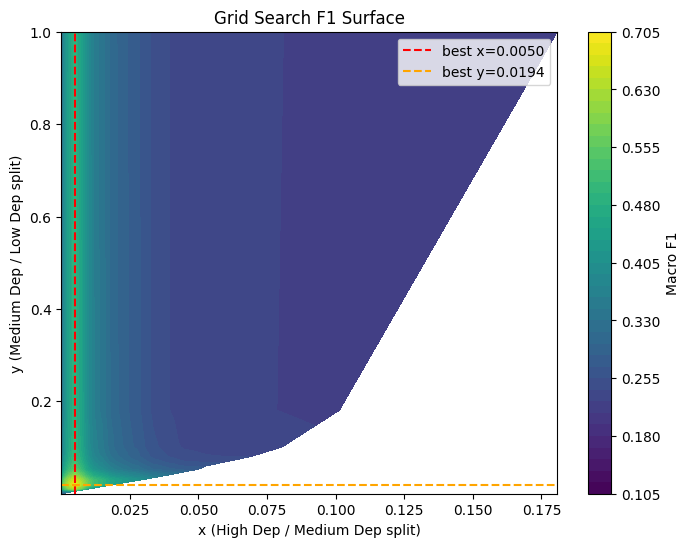

In [16]:
# Define grid
grid = np.sort(np.unique(np.quantile(
    accessibility_index_Kano['Accessibility_Index_Standard'], 
    np.linspace(0, 1, 200)
)))

scores      = accessibility_index_Kano['Accessibility_Index_Standard'].values
true_labels = accessibility_index_Kano['validation'].values.astype(int)

best_x, best_y, best_f1 = 0, 0, -1
results = []

for x, y in product(grid, grid):
    if x >= y:
        continue
    
    # Low score = High Deprivation (2), High score = Low Deprivation (0)
    preds = np.where(scores >= y, 0, np.where(scores >= x, 1, 2))
    f1 = f1_score(true_labels, preds, average='macro', zero_division=0)
    results.append({'x': x, 'y': y, 'f1': f1})
    
    if f1 > best_f1:
        best_f1, best_x, best_y = f1, x, y

print(f"Best x: {best_x:.6f}")
print(f"Best y: {best_y:.6f}")
print(f"Macro F1: {best_f1:.4f}")

# Visualise F1 surface
results_df = pd.DataFrame(results)
pivot = results_df.pivot_table(index='y', columns='x', values='f1')

plt.figure(figsize=(8, 6))
plt.contourf(pivot.columns, pivot.index, pivot.values, levels=50, cmap='viridis')
plt.colorbar(label='Macro F1')
plt.axvline(best_x, color='red', linestyle='--', label=f'best x={best_x:.4f}')
plt.axhline(best_y, color='orange', linestyle='--', label=f'best y={best_y:.4f}')
plt.xlabel('x (High Dep / Medium Dep split)')
plt.ylabel('y (Medium Dep / Low Dep split)')
plt.title('Grid Search F1 Surface')
plt.legend()
plt.show()

### Lagos - Emergency Obstetric Care (EmOC) Accessibility

In [17]:
# Select pilot city
pilot = 'Lagos'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [18]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (36677, 12)


output_model_subdomain_name
Morphological Informality                      11449
Emergency Obstetric Care Access Deprivation     6174
Flood Hazard                                    6041
Road Access Deprivation                         5607
General Healthcare Access Deprivation           5312
Drinking Water Access Deprivation               2094
Name: count, dtype: int64

In [19]:
# Enter subdomain
subdomain = 'Emergency Obstetric Care Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain_Lagos = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain_Lagos.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
543,aeb17088-241a-4f88-b94d-f33b3405552c,2025-06-11T11:53:23.15709+00:00,0.0,b1de59f5-f25e-43e9-848e-6010f3b75ec6,72ec5596-20c0-428a-b07e-6c7f9928b475,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,0,6.444213,3.406236
976,81175ec4-b7b0-4e38-b837-fdbb89553a1d,2025-06-14T06:03:52.863783+00:00,2.0,70bba171-fd70-4b77-9c8e-3cc139a0578a,07b350e2-4750-48a2-9b66-c26eac3642bd,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.478265,3.343269
1436,ee91dd05-2917-4756-8aa7-c17209fe1c4b,2025-06-11T13:54:03.268101+00:00,1.0,c9badf10-82b9-4d82-859a-f0fad50cc6ae,c1b3cdc7-a379-4fb3-8927-9c89193b213b,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.616911,3.378909
2500,fd14bf6c-1b28-4a46-ba46-95b1cfbbcf6f,2025-06-11T13:54:08.025594+00:00,1.0,c9badf10-82b9-4d82-859a-f0fad50cc6ae,8516e57a-d66a-4bf8-a657-5dfbb2cd634e,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.614478,3.376894
2814,79285926-2dac-435a-a8b3-39579a016568,2025-06-11T13:54:09.971835+00:00,2.0,c9badf10-82b9-4d82-859a-f0fad50cc6ae,7a0b15e5-fcf6-4834-88ba-377109700e30,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,2,6.614478,3.377896


In [20]:
accessibility_index_Lagos = gpd.read_file('deprivation-classification-Lagos.gpkg')
print(accessibility_index_Lagos.columns)

Index(['grid_id', 'longitude', 'latitude', 'lon_min', 'lat_min', 'lon_max',
       'lat_max', 'Accessibility_standard', 'result', 'focused', 'geometry'],
      dtype='object')


In [21]:
par_gdf = gpd.GeoDataFrame(
    par_subdomain_Lagos,
    geometry=gpd.points_from_xy(par_subdomain_Lagos['output_longitude'], 
                                 par_subdomain_Lagos['output_latitude']),
    crs=accessibility_index_Lagos.crs
)

joined = gpd.sjoin(par_gdf, accessibility_index_Lagos[['Accessibility_standard', 'geometry']], 
                    how="left", predicate="within")

par_subdomain_Lagos = par_subdomain_Lagos.copy()
par_subdomain_Lagos['Accessibility_standard'] = joined['Accessibility_standard'].values
par_subdomain_Lagos

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude,Accessibility_standard
543,aeb17088-241a-4f88-b94d-f33b3405552c,2025-06-11T11:53:23.15709+00:00,0.0,b1de59f5-f25e-43e9-848e-6010f3b75ec6,72ec5596-20c0-428a-b07e-6c7f9928b475,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,0,6.444213,3.406236,0.034107
976,81175ec4-b7b0-4e38-b837-fdbb89553a1d,2025-06-14T06:03:52.863783+00:00,2.0,70bba171-fd70-4b77-9c8e-3cc139a0578a,07b350e2-4750-48a2-9b66-c26eac3642bd,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.478265,3.343269,0.012845
1436,ee91dd05-2917-4756-8aa7-c17209fe1c4b,2025-06-11T13:54:03.268101+00:00,1.0,c9badf10-82b9-4d82-859a-f0fad50cc6ae,c1b3cdc7-a379-4fb3-8927-9c89193b213b,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.616911,3.378909,0.010623
2500,fd14bf6c-1b28-4a46-ba46-95b1cfbbcf6f,2025-06-11T13:54:08.025594+00:00,1.0,c9badf10-82b9-4d82-859a-f0fad50cc6ae,8516e57a-d66a-4bf8-a657-5dfbb2cd634e,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.614478,3.376894,0.007383
2814,79285926-2dac-435a-a8b3-39579a016568,2025-06-11T13:54:09.971835+00:00,2.0,c9badf10-82b9-4d82-859a-f0fad50cc6ae,7a0b15e5-fcf6-4834-88ba-377109700e30,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,2,6.614478,3.377896,0.006200
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81567,e709b96b-5e74-4aed-9aac-10d05081a16a,2025-08-28T13:16:28.294999+00:00,0.0,11bf793f-2f11-4a0c-8fb5-bb8fcd705449,32feb33f-bc9c-437b-a871-006832c9076d,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.482318,3.368329,0.011625
81568,bea4bee0-3ecf-4048-851a-4fa3ae8c639f,2025-08-28T13:16:34.525772+00:00,0.0,11bf793f-2f11-4a0c-8fb5-bb8fcd705449,9b0eec6b-4630-4032-9a67-2c469460d6c7,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.481508,3.368326,0.014101
81573,6a8415f9-603b-40b3-a605-1a6656b5f92a,2025-08-28T13:16:07.966729+00:00,0.0,11bf793f-2f11-4a0c-8fb5-bb8fcd705449,be741a89-5093-46b2-9b8b-ce8a6271af40,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.486372,3.368346,0.013680
81574,bb5c1663-0d0e-430a-b730-512f406a1a26,2025-08-28T13:15:55.426442+00:00,0.0,11bf793f-2f11-4a0c-8fb5-bb8fcd705449,4dc03c16-6381-4255-a3c7-147e26b3f4b1,1ac6e722-7ab9-4979-a5bf-1db62c6ef9b3,Lagos,Nigeria,Emergency Obstetric Care Access Deprivation,1,6.484751,3.368339,0.013652


In [28]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation'):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1
    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# Run on par_subdomain_Lagos instead of accessibility_index
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(par_subdomain_Lagos)
print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Lagos['optimised_result'] = np.where(
    par_subdomain_Lagos['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Lagos['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Lagos['validation'],
    par_subdomain_Lagos['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.007003
Best y threshold (Medium / Low split):  0.015060
Macro F1:  0.6898
Accuracy:  70.91%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.57      0.61      1523
Medium deprivation (1)       0.69      0.88      0.77      2521
  High deprivation (2)       0.80      0.61      0.69      2130

              accuracy                           0.71      6174
             macro avg       0.71      0.69      0.69      6174
          weighted avg       0.72      0.71      0.70      6174



#### Weighted Threshold Optimisation (Lagos)
- Replaces macro F1 (equal class weights) with a custom weighted F1:
- High (2): 0.45  |  Medium (1): 0.45  |  Low (0): 0.1
- This prioritises High and Medium deprivation classification accuracy

In [ ]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation',
                        class_weights={2: 0.45, 1: 0.45, 0: 0.10}): # adjust weights 
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1

    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            per_class_f1 = f1_score(true_labels, predictions, 
                                     average=None, labels=[0, 1, 2], 
                                     zero_division=0)
            weighted_f1 = sum(class_weights[c] * per_class_f1[c] for c in [0, 1, 2])
            if weighted_f1 > best_f1:
                best_f1 = weighted_f1
                best_x, best_y = x, y

    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# ---- Run for Lagos ----
print("Running weighted optimisation for Lagos...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(
    par_subdomain_Lagos,
    score_col='Accessibility_standard',
    class_weights={2: 0.45, 1: 0.45, 0: 0.10}
)

print("-" * 40)
print("LAGOS WEIGHTED OPTIMIZATION RESULTS")
print("-" * 40)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Weighted F1:  {best_f1:.4f}")
print(f"Accuracy:     {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Lagos['optimised_result'] = np.where(
    par_subdomain_Lagos['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Lagos['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Lagos['validation'],
    par_subdomain_Lagos['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running weighted optimisation for Kano...
----------------------------------------
LAGOS WEIGHTED OPTIMIZATION RESULTS
----------------------------------------
Best x threshold (High / Medium split): 0.007003
Best y threshold (Medium / Low split):  0.015060
Weighted F1:  0.7193
Accuracy:     70.91%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.57      0.61      1523
Medium deprivation (1)       0.69      0.88      0.77      2521
  High deprivation (2)       0.80      0.61      0.69      2130

              accuracy                           0.71      6174
             macro avg       0.71      0.69      0.69      6174
          weighted avg       0.72      0.71      0.70      6174



In [30]:
print("=== Original (output_result) ===")
print(classification_report(
    par_subdomain_Lagos['validation'],
    par_subdomain_Lagos['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    par_subdomain_Lagos['validation'],
    par_subdomain_Lagos['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.57      0.61      1523
Medium deprivation (1)       0.69      0.88      0.77      2521
  High deprivation (2)       0.80      0.61      0.69      2130

              accuracy                           0.71      6174
             macro avg       0.71      0.69      0.69      6174
          weighted avg       0.72      0.71      0.70      6174

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.65      0.57      0.61      1523
Medium deprivation (1)       0.69      0.88      0.77      2521
  High deprivation (2)       0.80      0.61      0.69      2130

              accuracy                           0.71      6174
             macro avg       0.71      0.69      0.69      6174
          weighted avg       0.72      0.71      0.70      6174



### Nairobi - Emergency Obstetric Care (EmOC) Accessibility

In [28]:
# Select pilot city
pilot = 'Nairobi'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [29]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (28317, 12)


output_model_subdomain_name
Morphological Informality                      11956
Road Access Deprivation                         7125
Emergency Obstetric Care Access Deprivation     3187
Flood Hazard                                    3095
Accumulated Waste Piles                         2873
General Healthcare Access Deprivation             81
Name: count, dtype: int64

In [30]:
# Enter subdomain
subdomain = 'Emergency Obstetric Care Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain_Nairobi = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain_Nairobi.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
47958,a3a4c625-96d3-4607-9b99-f232514ad4c0,2025-07-30T08:07:46.237607+00:00,1.0,3238d1a6-7f40-41b0-bd06-d94417973916,708e6586-3e7c-4b0a-8efc-144988afa1e3,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.883359
48643,387489fc-7fa1-496e-b1ea-1914c2352d06,2025-07-30T08:05:01.990103+00:00,2.0,3238d1a6-7f40-41b0-bd06-d94417973916,cedcac24-4f7f-4f81-87b8-8146379195f0,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.881363
74230,46aa1ea2-250f-447a-b686-3fbbd7a67feb,2025-07-30T12:56:56.286148+00:00,0.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,892e9666-d1df-412b-93b3-6a18d2195a84,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.314696,36.842428
74249,4213171f-ed7d-4d56-82f3-30cd36165d62,2025-07-30T12:57:00.998008+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,90b697fb-c13b-4d93-857b-f5707813db79,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.842421
74254,ba0f3f6e-1fbf-4d7d-8c66-1bd61cb0a767,2025-07-30T12:57:13.453612+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,6c9b77ce-e78b-44ba-9ab5-3ef37c645ffc,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.841423


In [31]:
accessibility_index_Nairobi = gpd.read_file('deprivation-classification-Nairobi.gpkg')
print(accessibility_index_Nairobi.columns)

Index(['grid_id', 'hcf_id', 'longitude_hcf', 'latitude_hcf', 'facility_name',
       'local_validation', 'population', 'duration_seconds', 'distance_km',
       'Weight', 'Pop_W_x', 'Pop_W_S', 'supply_demand_ratio', 'supply_W',
       'Accessibility', 'supply', 'Accessibility_standard', 'result',
       'focused', 'lon_min', 'lat_min', 'lon_max', 'lat_max', 'geometry'],
      dtype='object')


In [32]:
par_gdf = gpd.GeoDataFrame(
    par_subdomain_Nairobi,
    geometry=gpd.points_from_xy(par_subdomain_Nairobi['output_longitude'], 
                                 par_subdomain_Nairobi['output_latitude']),
    crs=accessibility_index_Nairobi.crs
)

joined = gpd.sjoin(par_gdf, accessibility_index_Nairobi[['Accessibility_standard', 'geometry']], 
                    how="left", predicate="within")

par_subdomain_Nairobi = par_subdomain_Nairobi.copy()
par_subdomain_Nairobi['Accessibility_standard'] = joined['Accessibility_standard'].values
par_subdomain_Nairobi

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude,Accessibility_standard
47958,a3a4c625-96d3-4607-9b99-f232514ad4c0,2025-07-30T08:07:46.237607+00:00,1.0,3238d1a6-7f40-41b0-bd06-d94417973916,708e6586-3e7c-4b0a-8efc-144988afa1e3,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.883359,0.068815
48643,387489fc-7fa1-496e-b1ea-1914c2352d06,2025-07-30T08:05:01.990103+00:00,2.0,3238d1a6-7f40-41b0-bd06-d94417973916,cedcac24-4f7f-4f81-87b8-8146379195f0,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.316314,36.881363,0.063474
74230,46aa1ea2-250f-447a-b686-3fbbd7a67feb,2025-07-30T12:56:56.286148+00:00,0.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,892e9666-d1df-412b-93b3-6a18d2195a84,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.314696,36.842428,0.128580
74249,4213171f-ed7d-4d56-82f3-30cd36165d62,2025-07-30T12:57:00.998008+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,90b697fb-c13b-4d93-857b-f5707813db79,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.842421,0.126473
74254,ba0f3f6e-1fbf-4d7d-8c66-1bd61cb0a767,2025-07-30T12:57:13.453612+00:00,1.0,bae64293-90a7-4d01-b833-6a3fb2dd57ec,6c9b77ce-e78b-44ba-9ab5-3ef37c645ffc,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,0,-1.313888,36.841423,0.123970
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84061,b0f0affa-eeed-4862-8998-bf963e884a87,2025-09-11T12:42:14.821978+00:00,1.0,05ec794f-ba27-4489-a84b-819b1f4b6463,d66e5306-3368-461a-9f69-6551558ac3be,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.313079,36.877341,0.071563
84131,960eec03-7a06-41c7-910c-aae4e64a863d,2025-09-11T12:41:17.474516+00:00,2.0,05ec794f-ba27-4489-a84b-819b1f4b6463,9bcd1fcf-f49d-4bab-baec-64689b790fdc,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.311461,36.878325,0.067899
84164,802258bc-e847-4c06-a6c7-4f007c6ca730,2025-09-11T12:41:46.783354+00:00,2.0,05ec794f-ba27-4489-a84b-819b1f4b6463,c147a676-c315-4162-98ef-a5ffaa32d7ae,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.313079,36.872352,0.074082
84172,382185e5-635a-49f2-926c-f153d5b2cd22,2025-09-11T12:42:01.22126+00:00,2.0,05ec794f-ba27-4489-a84b-819b1f4b6463,04629599-9807-4634-9e37-2259f6b67bcb,670877f9-f857-498d-b95a-f1fa077bc158,Nairobi,Kenya,Emergency Obstetric Care Access Deprivation,1,-1.312270,36.875338,0.072323


In [57]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation'):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1
    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# Run on par_subdomain_Nairobi instead of accessibility_index
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(par_subdomain_Nairobi)
print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Nairobi['optimised_result'] = np.where(
    par_subdomain_Nairobi['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Nairobi['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.043557
Best y threshold (Medium / Low split):  0.056020
Macro F1:  0.6644
Accuracy:  68.75%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.61      0.44      0.51      1039
Medium deprivation (1)       0.80      0.62      0.69       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.69      3187
             macro avg       0.70      0.66      0.66      3187
          weighted avg       0.69      0.69      0.67      3187



#### Weighted Threshold Optimisation (Nairobi)
- Replaces macro F1 (equal class weights) with a custom weighted F1:
- High (2): 0.5  |  Medium (1): 0.4  |  Low (0): 0.1
- This prioritises High and Medium deprivation classification accuracy

In [36]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation',
                        class_weights={2: 0.5, 1: 0.4, 0: 0.1}):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1

    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            per_class_f1 = f1_score(true_labels, predictions, 
                                     average=None, labels=[0, 1, 2], 
                                     zero_division=0)
            weighted_f1 = sum(class_weights[c] * per_class_f1[c] for c in [0, 1, 2])
            if weighted_f1 > best_f1:
                best_f1 = weighted_f1
                best_x, best_y = x, y

    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# ---- Run for Nairobi ----
print("Running weighted optimisation for Nairobi...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(
    par_subdomain_Nairobi,
    score_col='Accessibility_standard',
    class_weights={2: 0.5, 1: 0.4, 0: 0.1}
)

print("-" * 40)
print("NAIROBI WEIGHTED OPTIMIZATION RESULTS")
print("-" * 40)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Weighted F1:  {best_f1:.4f}")
print(f"Accuracy:     {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Nairobi['optimised_result'] = np.where(
    par_subdomain_Nairobi['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Nairobi['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running weighted optimisation for Nairobi...
----------------------------------------
NAIROBI WEIGHTED OPTIMIZATION RESULTS
----------------------------------------
Best x threshold (High / Medium split): 0.043557
Best y threshold (Medium / Low split):  0.063822
Weighted F1:  0.7232
Accuracy:     68.34%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.64      0.36      0.46      1039
Medium deprivation (1)       0.72      0.70      0.71       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.68      3187
             macro avg       0.68      0.66      0.65      3187
          weighted avg       0.68      0.68      0.66      3187



In [59]:
print("=== Original (output_result) ===")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    par_subdomain_Nairobi['validation'],
    par_subdomain_Nairobi['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.77      0.26      0.39      1039
Medium deprivation (1)       0.65      0.81      0.72       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.68      3187
             macro avg       0.70      0.67      0.63      3187
          weighted avg       0.70      0.68      0.64      3187

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.61      0.44      0.51      1039
Medium deprivation (1)       0.80      0.62      0.69       848
  High deprivation (2)       0.68      0.93      0.79      1300

              accuracy                           0.69      3187
             macro avg       0.70      0.66      0.66      3187
          weighted avg       0.69      0.69      0.67      3187



### Drinking Water Access Deprivation - Kano

In [9]:
# Select pilot city
pilot = 'Kano'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [10]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (24810, 12)


output_model_subdomain_name
Morphological Informality                      11009
Emergency Obstetric Care Access Deprivation     4434
General Healthcare Access Deprivation           4038
Road Access Deprivation                         3581
Drinking Water Access Deprivation               1748
Name: count, dtype: int64

In [11]:
# Enter subdomain
subdomain = 'Drinking Water Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain_Kano_DW = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain_Kano_DW.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
85708,d620d72d-86c5-4f4a-b941-ef93e4a78669,2025-10-29T10:59:40.594665+00:00,1.0,3e199a4c-7036-414a-9d8a-f221c5229a1f,fb5ca328-c59d-4f76-9ab3-361de387c157,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.973681,8.463031
85714,7f4dc474-3547-4e4b-ba48-ec61124a0022,2025-10-29T10:59:42.959221+00:00,1.0,3e199a4c-7036-414a-9d8a-f221c5229a1f,e0f6c0ef-d1a8-4ae4-b709-189656d2ce48,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.972865,8.463016
85715,48806da0-1f35-45a8-a360-373028821c57,2025-10-24T09:12:50.704973+00:00,1.0,4c0079ca-d0fa-48c7-9b0c-2bf2ae760ef9,b2d8c77d-e24f-4353-89ae-c120a62b0c2c,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.994887,8.518061
85716,9591a96f-c6bc-4041-913c-0177e942dcc5,2025-10-24T09:14:07.678654+00:00,1.0,4c0079ca-d0fa-48c7-9b0c-2bf2ae760ef9,df8964c9-e8e4-46b5-ba48-dbd5db618c88,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.995702,8.518077
85717,b31658ff-f07d-4228-8f00-6d18bd8531ff,2025-10-29T10:54:42.009989+00:00,2.0,6b96c10a-1d4d-4cfa-8e23-4b079f053035,7e70a97f-da5d-44c2-83dc-9cbb2455b917,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.958184,8.494084


In [12]:
accessibility_index_Kano_DW = gpd.read_file('drinking-water-access-class-Kano.gpkg')
print(accessibility_index_Kano_DW.columns)

Index(['grid_id', 'longitude', 'latitude', 'lon_min', 'lat_min', 'lon_max',
       'lat_max', 'Accessibility_standard', 'result', 'focused', 'geometry'],
      dtype='object')


In [13]:
par_gdf = gpd.GeoDataFrame(
    par_subdomain_Kano_DW,
    geometry=gpd.points_from_xy(par_subdomain_Kano_DW['output_longitude'], 
                                 par_subdomain_Kano_DW['output_latitude']),
    crs=accessibility_index_Kano_DW.crs
)

joined = gpd.sjoin(par_gdf, accessibility_index_Kano_DW[['Accessibility_standard', 'geometry']], 
                    how="left", predicate="within")

par_subdomain_Kano_DW = par_subdomain_Kano_DW.copy()
par_subdomain_Kano_DW['Accessibility_standard'] = joined['Accessibility_standard'].values
par_subdomain_Kano_DW

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude,Accessibility_standard
85708,d620d72d-86c5-4f4a-b941-ef93e4a78669,2025-10-29T10:59:40.594665+00:00,1.0,3e199a4c-7036-414a-9d8a-f221c5229a1f,fb5ca328-c59d-4f76-9ab3-361de387c157,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.973681,8.463031,0.001342
85714,7f4dc474-3547-4e4b-ba48-ec61124a0022,2025-10-29T10:59:42.959221+00:00,1.0,3e199a4c-7036-414a-9d8a-f221c5229a1f,e0f6c0ef-d1a8-4ae4-b709-189656d2ce48,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.972865,8.463016,0.001339
85715,48806da0-1f35-45a8-a360-373028821c57,2025-10-24T09:12:50.704973+00:00,1.0,4c0079ca-d0fa-48c7-9b0c-2bf2ae760ef9,b2d8c77d-e24f-4353-89ae-c120a62b0c2c,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.994887,8.518061,0.001360
85716,9591a96f-c6bc-4041-913c-0177e942dcc5,2025-10-24T09:14:07.678654+00:00,1.0,4c0079ca-d0fa-48c7-9b0c-2bf2ae760ef9,df8964c9-e8e4-46b5-ba48-dbd5db618c88,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,1,11.995702,8.518077,0.001310
85717,b31658ff-f07d-4228-8f00-6d18bd8531ff,2025-10-29T10:54:42.009989+00:00,2.0,6b96c10a-1d4d-4cfa-8e23-4b079f053035,7e70a97f-da5d-44c2-83dc-9cbb2455b917,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.958184,8.494084,0.000124
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87805,ee22ab36-fbb2-45f3-a2b5-09cf1cbbaca3,2025-10-29T12:50:20.807882+00:00,0.0,61a54b17-c5bc-4dfa-aea6-8071a1d885f6,6c6ad1ec-1fac-476a-933e-1a8a0e6ceb43,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.959815,8.486025,0.000300
87806,ca0e1b21-b6c6-4872-8a8f-94b374c371d1,2025-10-29T12:50:31.413149+00:00,0.0,61a54b17-c5bc-4dfa-aea6-8071a1d885f6,200354b3-0f2a-4ae5-82e4-4fb27af6fbad,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.959815,8.487036,0.000278
87807,7fa57a68-f57c-4bff-bf37-20df9ffe93c6,2025-10-29T12:50:40.489853+00:00,0.0,61a54b17-c5bc-4dfa-aea6-8071a1d885f6,a1cfd1a3-de90-4d8f-917d-da5056492b35,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.959815,8.488048,0.000257
87808,367e7ae8-6817-4ca2-a52c-eb4899ea7393,2025-10-29T12:50:51.652682+00:00,0.0,61a54b17-c5bc-4dfa-aea6-8071a1d885f6,672a3303-16d3-4a16-ba14-46779396bbdf,113d67d7-f1e2-468f-bd69-ef13006c5223,Kano,Nigeria,Drinking Water Access Deprivation,2,11.959815,8.489059,0.000221


In [14]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation'):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1
    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# Run on par_subdomain_Kano_DW instead of accessibility_index
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(par_subdomain_Kano_DW)
print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Kano_DW['optimised_result'] = np.where(
    par_subdomain_Kano_DW['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Kano_DW['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Kano_DW['validation'],
    par_subdomain_Kano_DW['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.000053
Best y threshold (Medium / Low split):  0.000391
Macro F1:  0.4903
Accuracy:  51.77%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.56      0.35      0.43       556
Medium deprivation (1)       0.61      0.58      0.60       909
  High deprivation (2)       0.34      0.63      0.44       283

              accuracy                           0.52      1748
             macro avg       0.50      0.52      0.49      1748
          weighted avg       0.55      0.52      0.52      1748



In [15]:
print("=== Original (output_result) ===")
print(classification_report(
    par_subdomain_Kano_DW['validation'],
    par_subdomain_Kano_DW['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    par_subdomain_Kano_DW['validation'],
    par_subdomain_Kano_DW['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.00      0.00      0.00       556
Medium deprivation (1)       0.42      0.13      0.20       909
  High deprivation (2)       0.19      0.99      0.32       283

              accuracy                           0.23      1748
             macro avg       0.20      0.37      0.17      1748
          weighted avg       0.25      0.23      0.16      1748

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.56      0.35      0.43       556
Medium deprivation (1)       0.61      0.58      0.60       909
  High deprivation (2)       0.34      0.63      0.44       283

              accuracy                           0.52      1748
             macro avg       0.50      0.52      0.49      1748
          weighted avg       0.55      0.52      0.52      1748



/opt/anaconda3/envs/ideamaps/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/ideamaps/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/ideamaps/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

### Drinking Water Access Deprivation - Lagos

In [16]:
# Select pilot city
pilot = 'Lagos'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
# par_expanded = pd.read_csv('/content/expanded_data.csv') # You need to upload this file
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [17]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (36677, 12)


output_model_subdomain_name
Morphological Informality                      11449
Emergency Obstetric Care Access Deprivation     6174
Flood Hazard                                    6041
Road Access Deprivation                         5607
General Healthcare Access Deprivation           5312
Drinking Water Access Deprivation               2094
Name: count, dtype: int64

In [18]:
# Enter subdomain
subdomain = 'Drinking Water Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain_Lagos_DW = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain_Lagos_DW.head()

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
86652,f4fd5884-4f0c-447a-a770-8ca60682588e,2026-01-19T13:36:39.843778+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,c8684b02-8df0-42be-a3d7-a91e7cd6a703,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.607992,3.409929
86662,3f998ad6-98bf-46a5-ae11-43303efca13f,2026-01-19T13:37:50.664284+00:00,2.0,d6f1f42d-d5d2-4917-9d3c-3e521292bb2f,68d77f3f-8165-4845-8b5e-31b07cd12937,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.416929
86674,6bcdb870-a47e-4c6b-83a1-b2f052017006,2026-01-19T13:38:16.554319+00:00,1.0,b7085b3b-71ca-4479-bf70-4335856cf086,64f88ea1-79b8-473c-ae3b-129610a31e24,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.415927
86675,78a7cec3-433d-496f-a73e-9552cdd22f41,2026-01-19T13:38:25.728696+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,15c6ba72-a907-4b96-992e-bb4000b482b6,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.605559,3.409919
86681,e484ee53-3376-44ea-ad72-8df989ee0585,2026-01-19T13:23:10.076725+00:00,1.0,b2559219-c7d6-47be-b589-0f58fda8686f,9b8314af-f480-4997-a030-79bedeb29d66,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,0,6.601505,3.427936


In [19]:
accessibility_index_Lagos_DW = gpd.read_file('drinking-water-access-class-Lagos.gpkg')
print(accessibility_index_Lagos_DW.columns)

Index(['grid_id', 'longitude', 'latitude', 'lon_min', 'lat_min', 'lon_max',
       'lat_max', 'population', 'duration_seconds', 'duration_min',
       'distance_km', 'waterpoint_id', 'category', 'dest_lat', 'dest_lon',
       'Weight', 'Pop_W_x', 'Pop_W_S', 'supply', 'supply_demand_ratio',
       'supply_W', 'Accessibility', 'Accessibility_standard', 'result',
       'result_calibrated', 'focused', 'geometry'],
      dtype='object')


In [20]:
par_gdf = gpd.GeoDataFrame(
    par_subdomain_Lagos_DW,
    geometry=gpd.points_from_xy(par_subdomain_Lagos_DW['output_longitude'], 
                                 par_subdomain_Lagos_DW['output_latitude']),
    crs=accessibility_index_Lagos_DW.crs
)

joined = gpd.sjoin(par_gdf, accessibility_index_Lagos_DW[['Accessibility_standard', 'geometry']], 
                    how="left", predicate="within")

par_subdomain_Lagos_DW = par_subdomain_Lagos_DW.copy()
par_subdomain_Lagos_DW['Accessibility_standard'] = joined['Accessibility_standard'].values
par_subdomain_Lagos_DW

,id,created_at,validation,user_id,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude,Accessibility_standard
86652,f4fd5884-4f0c-447a-a770-8ca60682588e,2026-01-19T13:36:39.843778+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,c8684b02-8df0-42be-a3d7-a91e7cd6a703,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.607992,3.409929,0.000566
86662,3f998ad6-98bf-46a5-ae11-43303efca13f,2026-01-19T13:37:50.664284+00:00,2.0,d6f1f42d-d5d2-4917-9d3c-3e521292bb2f,68d77f3f-8165-4845-8b5e-31b07cd12937,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.416929,0.000820
86674,6bcdb870-a47e-4c6b-83a1-b2f052017006,2026-01-19T13:38:16.554319+00:00,1.0,b7085b3b-71ca-4479-bf70-4335856cf086,64f88ea1-79b8-473c-ae3b-129610a31e24,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.415927,0.000816
86675,78a7cec3-433d-496f-a73e-9552cdd22f41,2026-01-19T13:38:25.728696+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,15c6ba72-a907-4b96-992e-bb4000b482b6,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.605559,3.409919,0.000712
86681,e484ee53-3376-44ea-ad72-8df989ee0585,2026-01-19T13:23:10.076725+00:00,1.0,b2559219-c7d6-47be-b589-0f58fda8686f,9b8314af-f480-4997-a030-79bedeb29d66,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,0,6.601505,3.427936,0.002081
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90287,d008f9cd-f490-4816-b13d-4c6ee0c91267,2026-01-23T19:15:57.957177+00:00,1.0,319ec468-a66b-4ebe-91f6-caf6048fc336,92d21d7b-6d25-4012-adb2-9648e4e9d39f,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.605559,3.440978,0.000368
90289,337252b7-094d-42b4-b8dd-408ea193250b,2026-01-23T19:16:00.722445+00:00,1.0,319ec468-a66b-4ebe-91f6-caf6048fc336,594f78b8-98ee-4178-a4c7-f8af18287a1d,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.605559,3.439976,0.000368
90291,66ae7aed-4371-4b54-bb89-ea6e2de4c928,2026-01-23T19:16:01.823784+00:00,1.0,319ec468-a66b-4ebe-91f6-caf6048fc336,86f99b77-85ca-4d3c-ace4-ffc07c670e9d,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.607181,3.441986,0.000368
90293,6bf1bdf1-08e6-4198-8d09-fc5daad55b72,2026-01-23T19:16:03.039934+00:00,1.0,319ec468-a66b-4ebe-91f6-caf6048fc336,8d1cf708-c2cb-4860-b835-6a42e561dd94,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.607181,3.440985,0.000368


In [21]:
def optimize_thresholds(df, score_col='Accessibility_standard', label_col='validation'):
    candidates  = np.sort(np.unique(np.quantile(df[score_col].dropna(), np.linspace(0, 1, 200))))
    scores      = df[score_col].values
    true_labels = df[label_col].values.astype(int)
    best_x, best_y, best_f1 = 0, 0, -1
    for i in range(len(candidates)):
        x = candidates[i]
        for j in range(i + 1, len(candidates)):
            y = candidates[j]
            predictions = np.where(scores >= y, 0,
                          np.where(scores >= x, 1, 2))
            f1 = f1_score(true_labels, predictions, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_x, best_y = x, y
    final_preds = np.where(scores >= best_y, 0, np.where(scores >= best_x, 1, 2))
    accuracy = (np.sum(final_preds == true_labels) / len(df)) * 100
    return best_x, best_y, best_f1, accuracy

# Run on par_subdomain_Lagos_DW instead of accessibility_index
print("Running optimization...")
optimal_x, optimal_y, best_f1, accuracy_pct = optimize_thresholds(par_subdomain_Lagos_DW)
print("-" * 30)
print("OPTIMIZATION RESULTS")
print("-" * 30)
print(f"Best x threshold (High / Medium split): {optimal_x:.6f}")
print(f"Best y threshold (Medium / Low split):  {optimal_y:.6f}")
print(f"Macro F1:  {best_f1:.4f}")
print(f"Accuracy:  {accuracy_pct:.2f}%")

# Apply optimal thresholds
par_subdomain_Lagos_DW['optimised_result'] = np.where(
    par_subdomain_Lagos_DW['Accessibility_standard'] >= optimal_y, 0,
    np.where(par_subdomain_Lagos_DW['Accessibility_standard'] >= optimal_x, 1, 2)
).astype(int)

print("\nClassification Report:")
print(classification_report(
    par_subdomain_Lagos_DW['validation'],
    par_subdomain_Lagos_DW['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

Running optimization...
------------------------------
OPTIMIZATION RESULTS
------------------------------
Best x threshold (High / Medium split): 0.000852
Best y threshold (Medium / Low split):  0.002039
Macro F1:  0.4274
Accuracy:  46.99%

Classification Report:
                        precision    recall  f1-score   support

   Low deprivation (0)       0.34      0.19      0.25       463
Medium deprivation (1)       0.54      0.45      0.49       996
  High deprivation (2)       0.45      0.71      0.55       635

              accuracy                           0.47      2094
             macro avg       0.44      0.45      0.43      2094
          weighted avg       0.47      0.47      0.45      2094



In [22]:
print("=== Original (output_result) ===")
print(classification_report(
    par_subdomain_Lagos_DW['validation'],
    par_subdomain_Lagos_DW['output_result'].astype(int),
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

print("=== Optimised ===")
print(classification_report(
    par_subdomain_Lagos_DW['validation'],
    par_subdomain_Lagos_DW['optimised_result'],
    target_names=['Low deprivation (0)', 'Medium deprivation (1)', 'High deprivation (2)']
))

=== Original (output_result) ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.32      0.67      0.43       463
Medium deprivation (1)       0.43      0.49      0.46       996
  High deprivation (2)       0.67      0.00      0.01       635

              accuracy                           0.38      2094
             macro avg       0.47      0.39      0.30      2094
          weighted avg       0.48      0.38      0.32      2094

=== Optimised ===
                        precision    recall  f1-score   support

   Low deprivation (0)       0.34      0.19      0.25       463
Medium deprivation (1)       0.54      0.45      0.49       996
  High deprivation (2)       0.45      0.71      0.55       635

              accuracy                           0.47      2094
             macro avg       0.44      0.45      0.43      2094
          weighted avg       0.47      0.47      0.45      2094

